In [1]:
%pip install -q requests pydantic python-dotenv pandas matplotlib ipykernel

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip freeze > requirements.txt

In [3]:
import os, re, sys, json, time, ast, operator, subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from dataclasses import dataclass, field
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field, ValidationError

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

assert os.getenv("OPENROUTER_API_KEY", "no key for openrouter in .env file!")

api_key = os.getenv("OPENROUTER_API_KEY")

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
HEADERS = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json"
}

MODELS = {"cheap": "xiaomi/mimo-v2.5", "mid": "tencent/hy3-preview", "strong": "deepseek/deepseek-v4-pro-0813"}

In [4]:
import requests
import threading
from dataclasses import dataclass, field

@dataclass
class Ledger:
    calls: list = field(default_factory=list)
    lock: object = field(default_factory=threading.Lock, repr=False)

    def add(self, tag, model, usage, seconds=0.0):
        p, c = usage.get("prompt_tokens", 0), usage.get("completion_tokens", 0)
        cost = usage.get("cost") or 0.0
        with self.lock:
            self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": p, "completion": c,
                               "cost": cost, "seconds": round(seconds, 2)})
        return cost

    @property
    def total(self):
        with self.lock:
            return sum(c["cost"] for c in self.calls)

    def table(self):
        with self.lock:
            calls = list(self.calls)
        df = pd.DataFrame(calls)
        return df.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                completion=("completion", "sum"), cost=("cost", "sum"),
                                                seconds=("seconds", "sum")).round(5)

ledger = Ledger()

In [5]:
def post_with_retry(body, attempts=4):
    last_error = "no response"
    for attempt in range(attempts):
        try:
            r = requests.post(CHAT_URL, headers=HEADERS, json=body, timeout=(15, 120))
        except requests.RequestException as e:
            last_error = type(e).__name__
        else:
            if r.status_code == 200:
                return r.json()
            if r.status_code in (429, 500, 502, 503):
                last_error = f"HTTP {r.status_code}"
            else:
                raise RuntimeError(f"HTTP {r.status_code} : {r.text[:5000]}")
        time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(f"OpenRouter unavailable: {last_error}")

In [6]:
MAX_TOKENS = 2000

def chat(messages, model, tools=None, tag="chat", temperature=None):
    body = {"model": model, "messages": messages, "usage": {"include": True}, "max_tokens": MAX_TOKENS}
    if tools:
        body["tools"] = tools
        body["tool_choice"] = "auto"
    if temperature is not None:
        body["temperature"] = temperature
    msg = {"content": ""}
    for _ in range(2):
        started = time.perf_counter()
        data = post_with_retry(body)
        ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
        msg = data["choices"][0]["message"]
        if (msg.get("content") or "").strip() or msg.get("tool_calls"):
            return msg
    return msg

In [7]:
msg = chat([{"role": "user", "content": "Ответь одним словом: какого цвета небо?"}], MODELS["cheap"], tag="hello")
msg["content"], ledger.calls[-1]

('Голубое.',
 {'tag': 'hello',
  'model': 'mimo-v2.5',
  'prompt': 262,
  'completion': 177,
  'cost': 5.09456e-05,
  'seconds': 9.57})

In [8]:
TRACES, IMG = Path("traces"), Path("img")
TRACES.mkdir(exist_ok=True)
IMG.mkdir(exist_ok=True)
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}

In [9]:
class Answer(BaseModel):
    reasoning: str = Field(description="brief reasoning")
    final: str = Field(description="final answer: a number or a short phrase, or 'unknown'")

SCHEMA_PROMPT = "Answer strictly with one JSON object matching this schema, no text around, no LaTeX, single line:\n{schema}"

def json_from(text):
    m = re.search(r"\{.*\}", text or "", re.S)
    if not m:
        raise ValueError("no JSON in the answer")
    return json.loads(m.group(0), strict=False)

def ask_structured(question, model, schema=Answer, attempts=3):
    messages = [
        {"role": "system", "content": SCHEMA_PROMPT.format(schema=json.dumps(schema.model_json_schema(), ensure_ascii=False))},
        {"role": "user", "content": question}
    ]
    for _ in range(attempts):
        msg = chat(messages, model, tag="struct")
        try:
            return schema.model_validate(json_from(msg["content"]))
        except (ValidationError, ValueError) as e:
            messages += [msg, {"role": "user", "content": f"Your answer failed schema validation: {e}. Reply with a strict JSON object."}]
    raise ValueError("the model could not produce valid JSON")

In [10]:
def normalize(text):
    text = re.sub(r"[^\w\s]", " ", str(text).lower().replace(",", ""))
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    return " ".join(text.split())

MONTHS = "january|february|march|april|may|june|july|august|september|october|november|december"

WORD_NUMS = {"zero": "0", "one": "1", "two": "2", "three": "3", "four": "4", "five": "5", "six": "6",
             "seven": "7", "eight": "8", "nine": "9", "ten": "10", "eleven": "11", "twelve": "12"}

def canon(text):
    text = re.sub(r"\bpercent(age points)?\b", " ", normalize(text))
    text = re.sub(rf"\b({MONTHS})\s+(\d{{1,2}})\b", r"\2 \1", text)
    for w, n in WORD_NUMS.items():
        text = re.sub(rf"\b{w}\b", n, text)
    return " ".join(text.split())


def strip_num_zeros(text):
    return re.sub(r"(\d+)\.0(?![\d])", r"\1", str(text))

def is_correct(task, answer):
    if task["source"] == "gsm8k":
        nums = re.findall(r"-?\d+(?:\.\d+)?", str(answer).replace(",", ""))
        return bool(nums) and abs(float(nums[-1]) - float(task["answer"])) < 1e-6
    gold, ans = strip_num_zeros(task["answer"]), strip_num_zeros(answer)
    return canon(gold) in canon(ans) or normalize(gold) in normalize(ans)

def summary(config, model, n, correct, cost, steps, seconds=0.0):
    return {"config": config, "model": model.split("/")[-1], "n": n, "accuracy": round(correct / n, 2),
            "cost_per_task": round(cost / n, 5), "cost_per_correct": round(cost / correct, 5) if correct else float("inf"),
            "avg_steps": round(steps, 2), "avg_seconds": round(seconds, 1)}

In [11]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv,
       ast.Pow: operator.pow, ast.USub: operator.neg, ast.Mod: operator.mod}

def evaluate(node):
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.left), evaluate(node.right))
    if isinstance(node, ast.UnaryOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.operand))
    raise ValueError("only numbers and arithmetic are allowed")

class CalcArgs(BaseModel):
    expr: str = Field(description="arithmetic expression, e.g. 17*23+5")

def calculator(expr: str) -> str:
    try:
        val = evaluate(ast.parse(expr.replace(",", "."), mode="eval").body)
        return str(int(val)) if float(val).is_integer() else f"{val:.4f}".rstrip("0")
    except Exception as e:
        return f"calculation error: {e}"

register(calculator, CalcArgs, "Evaluates an arithmetic expression: numbers, parentheses, + - * / ** %")

In [12]:
SYSTEM_WIKI = ("You answer questions about events of 2025 and 2026. Never answer from memory: "
               "use web_search to find the right Wikipedia article, then page_find to look inside long articles "
               "such as '2026 in <country or field>' for the specific fact. "
               "For arithmetic or date math use the calculator. Do not repeat the same call. "
               "When done, write the last line as FINAL: <short answer>.")

SYSTEM_ARXIV = ("You answer questions about recent AI research papers (2025-2026). Never answer from memory: "
                "use arxiv_search with distinctive keywords, ideally the system or benchmark name from the question. "
                "Read the returned abstracts: the fact you need is usually stated there. "
                "If a search returns an error or nothing, retry once with 1-2 different keywords, then move on. "
                "You may use the calculator for simple arithmetic on numbers from abstracts. "
                "Do not repeat the same call. When done, write the last line as FINAL: <short answer>.")

@dataclass
class Run:
    question: str
    answer: str
    steps: int
    messages: list
    cost: float = 0.0
    seconds: float = 0.0

def looped(seen, calls):
    keys = [(c["function"]["name"], c["function"]["arguments"]) for c in calls]
    repeated = any(k in seen for k in keys)
    seen.update(keys)
    return repeated

def finish(model, messages, step):
    del messages[-1]
    messages.append({"role": "user", "content": "Tools are now unavailable. Answer from what you already know, last line FINAL: <answer>."})
    msg = chat(messages, model, tag="agent")
    messages.append(msg)
    return msg.get("content") or "", step + 1

def run_tool(call):
    name = call["function"]["name"]
    try:
        spec = TOOLS[name]
        args = spec["args"].model_validate_json(call["function"]["arguments"])
        result = spec["fn"](**args.model_dump())
    except Exception as e:
        result = f"failed to call tool {name}: {e}"
    return {"role": "tool", "tool_call_id": call["id"], "content": str(result)[:6000]}

def agent_loop(messages, model, tool_names, max_steps):
    seen = set()
    for step in range(1, max_steps + 1):
        msg = chat(messages, model, tools=[TOOLS[n]["schema"] for n in tool_names] or None, tag="agent")
        messages.append(msg)
        calls = msg.get("tool_calls") or []
        if not calls:
            return msg.get("content") or "", step
        if looped(seen, calls) or step == max_steps:
            return finish(model, messages, step)
        messages += [run_tool(c) for c in calls]

SYSTEM_NO_TOOLS = ("You answer questions. No tools are available in this run, so answer from your own knowledge. "
                   "Do not attempt to call any tools. Write the last line as FINAL: <short answer>.")

def agent(question, model, tool_names, max_steps=8):
    if not tool_names:
        system = SYSTEM_NO_TOOLS
    elif "arxiv_search" in tool_names:
        system = SYSTEM_ARXIV
    else:
        system = SYSTEM_WIKI
    messages = [{"role": "system", "content": system}, {"role": "user", "content": question}]
    before, started = ledger.total, time.perf_counter()
    answer, steps = agent_loop(messages, model, tool_names, max_steps)
    return Run(question, answer, steps, messages, ledger.total - before, time.perf_counter() - started)


def show_trace(run):
    for m in run.messages[1:]:
        calls = "; ".join(f"{c['function']['name']}{c['function']['arguments']}" for c in m.get("tool_calls") or [])
        text = " ".join((m.get("content") or "").split())[:180]
        print(f"{m['role']:9s}| {text} {calls}")
    print(f"steps: {run.steps}, cost: {run.cost * 100:.3f} cents, seconds: {run.seconds:.1f}")

In [13]:
import threading

WIKI = "https://en.wikipedia.org/w/api.php"
WIKI_HEADERS = {"User-Agent": "agents-course-hw01/1.0 (educational project)"}

class Throttle:
    def __init__(self, interval):
        self.interval = interval
        self.lock = threading.Lock()
        self.last = 0.0

    def wait(self):
        with self.lock:
            now = time.perf_counter()
            delay = self.last + self.interval - now
            self.last = max(now, self.last + self.interval)
        if delay > 0:
            time.sleep(delay)

WIKI_THROTTLE = Throttle(0.6)
ARXIV_THROTTLE = Throttle(3.2)


def wiki(params, attempts=4):
    problem = "no response"
    for attempt in range(attempts):
        WIKI_THROTTLE.wait()
        try:
            r = requests.get(WIKI, params={**params, "format": "json"}, headers=WIKI_HEADERS, timeout=(10, 20))
            if r.status_code == 200 and r.headers.get("content-type", "").startswith("application/json"):
                return r.json()["query"]
            problem = f"HTTP {r.status_code}"
        except requests.RequestException as e:
            problem = type(e).__name__
        time.sleep(2.0 + 2.0 * attempt)
    raise RuntimeError(f"Wikipedia unavailable: {problem}")


class SearchArgs(BaseModel):
    query: str = Field(description="short search query: a name, a title, a term")

class PageFindArgs(BaseModel):
    title: str = Field(description="exact Wikipedia article title, e.g. '2026 in Japan'")
    keywords: str = Field(description="two to five keywords from the question")

class ExecArgs(BaseModel):
    code: str = Field(description="Python code; print the result with print()")

def web_search(query: str) -> str:
    hits = wiki({"action": "query", "list": "search", "srsearch": query, "srlimit": 3})["search"]
    if not hits:
        return "nothing found"
    pages = wiki({"action": "query", "prop": "extracts", "explaintext": 1, "exintro": 1, "titles": hits[0]["title"]})["pages"]
    text = " ".join(next(iter(pages.values())).get("extract", "").split())[:1500]
    others = ", ".join(h["title"] for h in hits[1:])
    return f"[{hits[0]['title']}] {text}" + (f" | other articles: {others}" if others else "")

def page_find(title, keywords):
    pages = wiki({"action": "query", "prop": "extracts", "explaintext": 1, "titles": title, "redirects": 1})["pages"]
    text = next(iter(pages.values())).get("extract", "")
    if not text:
        return "no such page"
    words = [w for w in re.findall(r"\w+", keywords.lower()) if len(w) > 2]
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    hits = [l for l in lines if sum(w in l.lower() for w in words) >= max(1, (len(words) + 1) // 2)]
    return "\n".join(h[:400] for h in hits[:6]) or "keywords not found on the page"

def python_exec(code: str) -> str:
    try:
        r = subprocess.run([sys.executable, "-I", "-c", code], capture_output=True, text=True, timeout=5)
    except subprocess.TimeoutExpired:
        return "code exceeded 5 s"
    out = (r.stdout + r.stderr).strip()
    return out[:5000] if out else "code ran but printed nothing"

class ArxivSearchArgs(BaseModel):
    query: str = Field(description="distinctive keywords from the question: a system or benchmark name, 2-4 words")

def arxiv_search(query: str) -> str:
    words = [w for w in re.findall(r"[\w-]+", str(query)) if len(w) > 1][:6]
    if not words:
        return "nothing found"
    problem = "no response"
    for attempt in range(4):
        ARXIV_THROTTLE.wait()
        try:
            r = requests.get("http://export.arxiv.org/api/query",
                             params={"search_query": " AND ".join(f"all:{w}" for w in words),
                                     "start": 0, "max_results": 3, "sortBy": "relevance"},
                             headers=WIKI_HEADERS, timeout=(15, 40))
        except requests.RequestException as e:
            problem = type(e).__name__
        else:
            if r.status_code == 200 and r.headers.get("content-type", "").startswith("application/atom+xml"):
                entries = re.findall(r"<entry>(.*?)</entry>", r.text, re.S)
                out = []
                for e in entries[:3]:
                    title = re.search(r"<title>(.*?)</title>", e, re.S)
                    summary = re.search(r"<summary>(.*?)</summary>", e, re.S)
                    link = re.search(r'href="(https?://arxiv\.org/abs/[^"]+)"', e)
                    t = " ".join((title.group(1) if title else "").split())
                    snip = " ".join((summary.group(1) if summary else "").split())[:1800]
                    out.append(f"[{t}] {snip}" + (f" ({link.group(1)})" if link else ""))
                return "\n---\n".join(out) if out else "nothing found"
            problem = f"HTTP {r.status_code}"
        time.sleep(4.0 * (attempt + 1))
    return f"arxiv error: {problem}"

In [14]:
register(web_search, SearchArgs, "Searches English Wikipedia and returns the intro of the best article plus titles of two more")
register(page_find, PageFindArgs, "Looks inside the full text of a Wikipedia article (e.g. '2026 in Japan') and returns the lines containing the keywords")
register(python_exec, ExecArgs, "Runs Python code in a separate process and returns what it printed")

assert calculator("2+2") == "4"
assert calculator("2**10") == "1024"
assert calculator("").startswith("calculation error")
assert "calculation error" in calculator("__import__('os')")
try:
    assert web_search("Scott Derrickson").startswith("[Scott Derrickson]")
    assert web_search("qwxzv 1234567 nonsense") == "nothing found"
except Exception as e:
    print("network-dependent tests skipped (VPN/network):", type(e).__name__)
assert python_exec("print(sum(range(10)))") == "45"
assert python_exec("x = 1") == "code ran but printed nothing"
assert "ZeroDivisionError" in python_exec("1/0")
assert "code exceeded 5 s" in python_exec("import time; time.sleep(10)")
try:
    assert page_find("2026 in Japan", "Japan March 2026") != "keywords not found on the page"
    assert page_find("2026 in Japan", "qwxzv qqq") == "keywords not found on the page"
    assert page_find("No Such Page qwxzv", "2026") == "no such page"
except Exception as e:
    print("network-dependent tests skipped (VPN/network):", type(e).__name__)

assert "failed to call tool page_find" in run_tool({"id": "t1", "function": {"name": "page_find", "arguments": json.dumps({"title": "2026 in Japan"})}})["content"]
assert "failed to call tool no_such_tool" in run_tool({"id": "t2", "function": {"name": "no_such_tool", "arguments": "{}"}})["content"]
"all tool tests passed"

register(arxiv_search, ArxivSearchArgs, "Searches arXiv for research papers and returns titles with abstract snippets; use it for questions about AI and agent research")

_ar = arxiv_search("agent harness")
assert "arxiv.org/abs/" in _ar, _ar[:200]
assert arxiv_search("zzqq wumpus 4711") == "nothing found"
assert "failed to call tool arxiv_search" in run_tool({"id": "t3", "function": {"name": "arxiv_search", "arguments": json.dumps({})}})["content"]
"arxiv tool tests passed"

'arxiv tool tests passed'

In [15]:
def final_answer(text):
    m = re.search(r"FINAL:\s*(.+)", text or "")
    return m.group(1).strip() if m else (text or "").strip()

def cached_row(config, model, task, trace_path):
    old = json.loads(trace_path.read_text(encoding="utf-8"))
    if isinstance(old.get("row"), dict):
        return old["row"]
    msgs = old.get("messages") or []
    return {"config": config, "model": model.split("/")[-1], "id": task["id"], "source": task["source"],
            "correct": is_correct(task, final_answer(old.get("answer") or "")), "steps": sum(m.get("role") == "assistant" for m in msgs),
            "tool_calls": sum(m.get("role") == "tool" for m in msgs), "cost": old.get("cost") or 0.0,
            "seconds": 0.0, "answer": final_answer(old.get("answer") or "")[:60], "gold": task["answer"]}

def one_task(task, model, tool_names, config, folder):
    trace_path = folder / f"{task['id']}.json"
    if trace_path.exists():
        return cached_row(config, model, task, trace_path), True
    try:
        run = agent(task["question"], model, tool_names)
    except Exception as e:
        run = Run(task["question"], f"error: {e}", 0, [])
    ok = is_correct(task, final_answer(run.answer))
    row = {"config": config, "model": model.split("/")[-1], "id": task["id"], "source": task["source"],
           "correct": ok, "steps": run.steps, "tool_calls": sum(m["role"] == "tool" for m in run.messages),
           "cost": run.cost, "seconds": round(run.seconds, 1), "answer": final_answer(run.answer)[:60], "gold": task["answer"]}
    trace_path.write_text(json.dumps({"task": task, "answer": run.answer, "correct": ok, "cost": run.cost,
                                      "messages": run.messages, "row": row}, ensure_ascii=False, indent=1), encoding="utf-8")
    return row, False

def run_tasks(tasks, model, tool_names, config, workers=5):
    folder = TRACES / config / model.split("/")[-1]
    folder.mkdir(parents=True, exist_ok=True)
    rows, t0, done = [None] * len(tasks), time.perf_counter(), 0
    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = {pool.submit(one_task, task, model, tool_names, config, folder): i for i, task in enumerate(tasks)}
        for fut in as_completed(futures):
            i = futures[fut]
            try:
                row, cached = fut.result()
            except Exception as e:
                row = {"config": config, "model": model.split("/")[-1], "id": tasks[i]["id"], "source": tasks[i]["source"],
                       "correct": False, "steps": 0, "tool_calls": 0, "cost": 0.0, "seconds": 0.0,
                       "answer": f"error: {e}", "gold": tasks[i]["answer"]}
                cached = False
            rows[i] = row
            done += 1
            mark = "cached" if cached else f"ok={row['correct']} steps={row['steps']} tools={row['tool_calls']}"
            print(f"[{config}] {done}/{len(tasks)} {row['id']} {mark} ${row['cost']:.4f} "
                  f"{row['seconds']}s, elapsed {time.perf_counter() - t0:.0f}s", flush=True)
    return pd.DataFrame(rows)


def report(results):
    rows = [summary(config, model, len(df), int(df["correct"].sum()), df["cost"].sum(), df["steps"].mean(), df["seconds"].mean())
            for (config, model), df in results.groupby(["config", "model"])]
    return pd.DataFrame(rows).sort_values("cost_per_task").reset_index(drop=True)

def money_chart(table, path="img/homework.png"):
    fig, ax = plt.subplots(figsize=(8, 5))
    for _, r in table.iterrows():
        cascade_row = "cascade" in r["config"] or "каскад" in r["config"]
        color = COLORS["red"] if cascade_row else COLORS["amber"] if "deepseek-v4-pro" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    fontsize=8, xytext=(6, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("cost per task, cents (log scale)")
    ax.set_ylabel("share of correct answers, %")
    ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

def steps_chart(results):
    g = results.groupby("config").agg(steps=("steps", "mean"), tool_calls=("tool_calls", "mean"), seconds=("seconds", "mean"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    g[["steps", "tool_calls"]].plot.bar(ax=axes[0], color=[COLORS["violet"], COLORS["teal"]], rot=12)
    axes[0].set_ylabel("average per task")
    g["seconds"].plot.bar(ax=axes[1], color=COLORS["amber"], rot=12)
    axes[1].set_ylabel("seconds per task")
    for ax in axes:
        ax.grid(alpha=0.3, axis="y")
        ax.set_xlabel("")
    fig.tight_layout()
    return fig

BEST_TOOLS = ["web_search", "page_find", "calculator"]
ARXIV_TOOLS = ["arxiv_search", "page_find", "calculator"]

In [16]:
def load_fresh(path=None):
    for p in [path, Path("data/fresh.jsonl"), Path("fresh_2026.jsonl")]:
        if p and Path(p).exists():
            return [json.loads(l) for l in Path(p).read_text(encoding="utf-8").splitlines() if l.strip()]
    raise FileNotFoundError("data/fresh.jsonl not found")

FRESH = load_fresh()
len(FRESH), FRESH[0]["question"]

(40,
 'What is the name of the multimodal unified structured execution harness for MLLMs introduced in June 2026?')

In [17]:
run = agent("What is 17 * 23 + 5? Use the calculator.", MODELS["cheap"], ["calculator"])
show_trace(run)

user     | What is 17 * 23 + 5? Use the calculator. 
assistant|  calculator{"expr": "17 * 23 + 5"}
tool     | 396 
assistant| The result of **17 × 23 + 5** is **396**. FINAL: 396 
steps: 2, cost: 0.010 cents, seconds: 3.9


In [18]:
run = agent(FRESH[0]["question"], MODELS["cheap"], BEST_TOOLS)
show_trace(run)

user     | What is the name of the multimodal unified structured execution harness for MLLMs introduced in June 2026? 
assistant|  web_search{"query": "multimodal unified structured execution harness MLLM June 2026"}
tool     | nothing found 
assistant|  web_search{"query": "multimodal unified structured execution harness MLLM 2026"}
tool     | nothing found 
assistant|  web_search{"query": "structured execution harness MLLM 2026"}
tool     | nothing found 
assistant|  web_search{"query": "unified structured execution harness multimodal 2026"}; web_search{"query": "MULLH multimodal execution harness MLLM 2026"}
tool     | [Glossary of artificial intelligence] This glossary of artificial intelligence is a list of definitions of terms and concepts relevant to the study of artificial intelligence (AI), 
tool     | nothing found 
assistant|  web_search{"query": "USEH MLLM structured execution harness 2026"}; web_search{"query": "MUSCLE multimodal LLM execution framework 2026"}
tool     | n

[cheap, no tools] 1/40 research-1 cached $0.0004 16.7s, elapsed 0s
[cheap, no tools] 2/40 research-2 cached $0.0005 18.0s, elapsed 0s
[cheap, no tools] 3/40 research-5 cached $0.0029 88.7s, elapsed 0s
[cheap, no tools] 4/40 research-3 cached $0.0003 14.5s, elapsed 0s
[cheap, no tools] 5/40 research-6 cached $0.0008 25.0s, elapsed 0s
[cheap, no tools] 6/40 research-4 cached $0.0002 13.6s, elapsed 0s
[cheap, no tools] 7/40 research-7 cached $0.0012 50.1s, elapsed 0s
[cheap, no tools] 8/40 research-10 cached $0.0001 8.7s, elapsed 0s
[cheap, no tools] 9/40 research-9 cached $0.0001 13.7s, elapsed 0s
[cheap, no tools] 10/40 research-8 cached $0.0002 9.9s, elapsed 0s
[cheap, no tools] 11/40 research-11 cached $0.0004 12.0s, elapsed 0s
[cheap, no tools] 12/40 research-15 cached $0.0002 9.3s, elapsed 0s
[cheap, no tools] 13/40 research-12 cached $0.0011 30.6s, elapsed 0s
[cheap, no tools] 14/40 research-14 cached $0.0014 28.2s, elapsed 0s
[cheap, no tools] 15/40 research-13 cached $0.0003 17.3

,config,model,n,accuracy,cost_per_task,cost_per_correct,avg_steps,avg_seconds
0,"cheap, arxiv + page",mimo-v2.5,40,0.97,0.00106,0.00108,2.35,21.9
1,"cheap, no tools",mimo-v2.5,40,0.00,0.00133,inf,1.00,35.5
2,"cheap, search + page",mimo-v2.5,40,0.00,0.00285,inf,8.15,87.2
3,"cheap, search only",mimo-v2.5,40,0.00,0.00286,inf,8.38,86.9
4,"mid, best tools",hy3-preview,40,0.00,0.00677,inf,5.30,62.4
5,"strong, arxiv + page",deepseek-v4-pro-0813,40,1.00,0.00815,0.00815,2.12,18.3
6,"strong, no tools",deepseek-v4-pro-0813,40,0.00,0.02083,inf,1.00,32.9


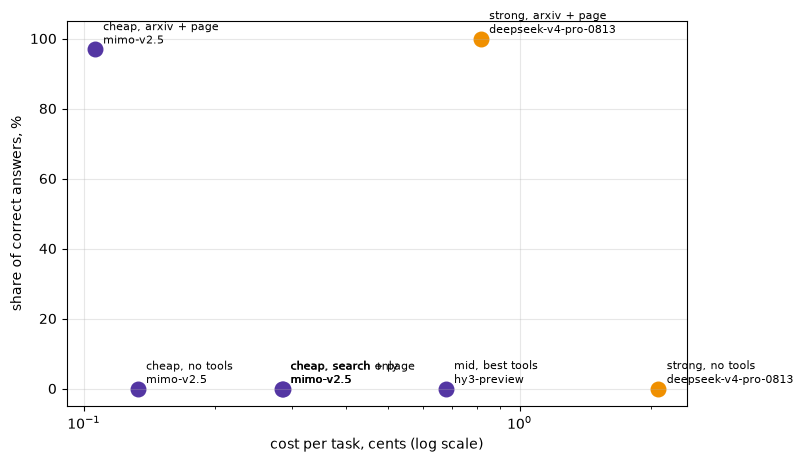

In [19]:
RUN_SET = FRESH
frames = [
    run_tasks(RUN_SET, MODELS["cheap"], [], "cheap, no tools"),
    run_tasks(RUN_SET, MODELS["cheap"], ["web_search"], "cheap, search only"),
    run_tasks(RUN_SET, MODELS["cheap"], BEST_TOOLS, "cheap, search + page"),
    run_tasks(RUN_SET, MODELS["mid"], BEST_TOOLS, "mid, best tools"),
]
frames.append(run_tasks(RUN_SET, MODELS["strong"], [], "strong, no tools"))
frames.append(run_tasks(RUN_SET, MODELS["cheap"], ARXIV_TOOLS, "cheap, arxiv + page"))
frames.append(run_tasks(RUN_SET, MODELS["strong"], ARXIV_TOOLS, "strong, arxiv + page"))
results = pd.concat(frames, ignore_index=True)
results.to_csv("results_raw.csv", index=False)
table = report(results)
Path("results.md").write_text(table.to_string(index=False), encoding="utf-8")
money_chart(table, "img/homework.png")
table

In [20]:
ledger.table(), round(ledger.total, 3)

(                 calls  prompt  completion     cost  seconds
 tag   model                                                 
 agent mimo-v2.5     11   10481        1097  0.00108    34.57
 hello mimo-v2.5      1     262         177  0.00005     9.57,
 0.001)

In [21]:
CASCADE_TOOLS = ["arxiv_search", "page_find", "calculator"]

class Confident(BaseModel):
    reasoning: str = Field(description="brief reasoning")
    final: str = Field(description="final answer")
    confidence: float = Field(description="honest confidence in the answer, from 0 to 1")

MEMO_PATH = Path("cascade_memo.json")
MEMO = json.loads(MEMO_PATH.read_text(encoding="utf-8")) if MEMO_PATH.exists() else {}

def memo_key(task, model, tools):
    return f"{task['id']}|{model}|{','.join(tools)}"

def agent_confident(task, model, tools):
    key = memo_key(task, model, tools)
    if key not in MEMO:
        before, started = ledger.total, time.perf_counter()
        try:
            run = agent(task["question"], model, tools)
            final = final_answer(run.answer)
            check = ask_structured(f"Question: {task['question']}\nProposed answer: {final}\n"
                                   "Rate your honest confidence that the proposed answer is correct, from 0 to 1.",
                                   model, Confident)
            MEMO[key] = {"final": final, "confidence": check.confidence, "cost": ledger.total - before,
                         "seconds": time.perf_counter() - started}
        except Exception:
            MEMO[key] = {"final": "", "confidence": 0.0, "cost": ledger.total - before, "seconds": 0.0}
        MEMO_PATH.write_text(json.dumps(MEMO, ensure_ascii=False), encoding="utf-8")
    return dict(MEMO[key])


def cascade(task, threshold):
    cheap = agent_confident(task, MODELS["cheap"], CASCADE_TOOLS)
    if cheap["confidence"] >= threshold:
        return {**cheap, "correct": is_correct(task, cheap["final"]), "escalated": False}
    strong = agent_confident(task, MODELS["strong"], CASCADE_TOOLS)
    return {**strong, "correct": is_correct(task, strong["final"]), "escalated": True}

def cascade_sweep(tasks, thresholds):
    rows = []
    for th in thresholds:
        outs = [cascade(t, th) for t in tasks]
        rows.append({"threshold": th, "accuracy": sum(o["correct"] for o in outs) / len(outs),
                     "cost_per_task": sum(o["cost"] for o in outs) / len(outs),
                     "escalated": sum(o["escalated"] for o in outs) / len(outs)})
    df = pd.DataFrame(rows)
    df["cost_per_correct"] = df["cost_per_task"] / df["accuracy"].replace(0, float("nan"))
    return df.round(5)

def cascade_chart(df):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(df["cost_per_task"] * 100, df["accuracy"] * 100, marker="o", color=COLORS["red"])
    for _, r in df.iterrows():
        ax.annotate(f"threshold {r['threshold']}, escalated {r['escalated']:.0%}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    xytext=(6, -12), textcoords="offset points", fontsize=8)
    ax.set_xlabel("cost per task, cents")
    ax.set_ylabel("share of correct answers, %")
    ax.grid(alpha=0.3)
    return fig

CASCADE_SET = RUN_SET[:30]
cascade_df = cascade_sweep(CASCADE_SET, [0.0, 0.7, 0.85, 1.01])
cascade_df

,threshold,accuracy,cost_per_task,escalated,cost_per_correct
0,0.00,1.0,0.00132,0.00000,0.00132
1,0.70,1.0,0.00865,0.93333,0.00865
2,0.85,1.0,0.00865,0.93333,0.00865
3,1.01,1.0,0.00913,1.00000,0.00913


,config,model,n,accuracy,cost_per_task,cost_per_correct,avg_steps,avg_seconds
0,"cheap, arxiv + page",mimo-v2.5,40,0.97,0.00106,0.00108,2.35,21.9
1,"cheap, no tools",mimo-v2.5,40,0.00,0.00133,inf,1.00,35.5
2,"cheap, search + page",mimo-v2.5,40,0.00,0.00285,inf,8.15,87.2
3,"cheap, search only",mimo-v2.5,40,0.00,0.00286,inf,8.38,86.9
4,"mid, best tools",hy3-preview,40,0.00,0.00677,inf,5.30,62.4
5,"strong, arxiv + page",deepseek-v4-pro-0813,40,1.00,0.00815,0.00815,2.12,18.3
6,"strong, no tools",deepseek-v4-pro-0813,40,0.00,0.02083,inf,1.00,32.9
7,"cascade, threshold 0.0",mimo-v2.5 + deepseek-v4-pro-0813,30,1.00,0.00132,0.00132,1.00,0.0
8,"cascade, threshold 0.7",mimo-v2.5 + deepseek-v4-pro-0813,30,1.00,0.00865,0.00865,1.00,0.0
9,"cascade, threshold 0.85",mimo-v2.5 + deepseek-v4-pro-0813,30,1.00,0.00865,0.00865,1.00,0.0


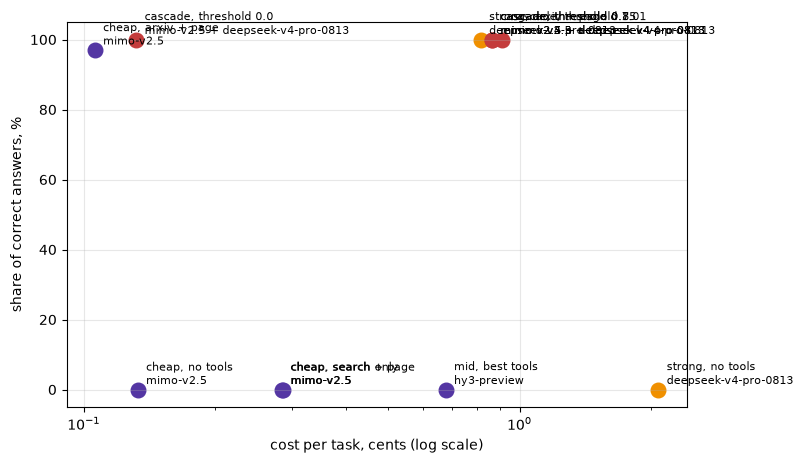

In [22]:
extra = pd.DataFrame([{"config": f"cascade, threshold {r.threshold}", "model": "mimo-v2.5 + deepseek-v4-pro-0813", "n": len(CASCADE_SET),
                       "accuracy": r.accuracy, "cost_per_task": r.cost_per_task, "cost_per_correct": r.cost_per_correct,
                       "avg_steps": 1, "avg_seconds": 0} for r in cascade_df.itertuples()])
money_chart(pd.concat([table, extra], ignore_index=True), "img/homework_all.png")
pd.concat([table, extra], ignore_index=True)

In [23]:
ledger.table(), round(ledger.total, 3)

(                 calls  prompt  completion     cost  seconds
 tag   model                                                 
 agent mimo-v2.5     11   10481        1097  0.00108    34.57
 hello mimo-v2.5      1     262         177  0.00005     9.57,
 0.001)